Inspect and visualize ranges and distributions of generated data

Imports

In [1]:
import os
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from src.data_utils import unpickle_data, get_data_scalars_dict, torch_calc_derivatives_to_numpy
from src.utils import get_off_diagonal, get_project_root

PROJECT_ROOT = get_project_root()

Args

In [2]:
# Path to a pickled file with data. Should be of the form /data/generated/<data_name>/pickled/<something>.pkl
data_path: str | os.PathLike = PROJECT_ROOT / "data/generated/L-32-g_0p5_0p8-rd-1e-04-si_64-steps_1200-zero_mom-MID/pickled/test.pkl"

Methods

In [3]:
def easy_split_diag(rho):
    diag = np.diagonal(rho, axis1=-2, axis2=-1)
    off_diag = get_off_diagonal(torch.tensor(rho)).numpy()
    return diag, off_diag

def get_deltas(data):
    delta_data = [comp[:, 1:] - comp[:, :-1] for comp in data]
    return delta_data

def get_rho_variants(rho):
    rho_real, rho_imag = rho.real, rho.imag
    rho_diag, rho_off_diag = easy_split_diag(rho)
    rho_diag = rho_diag.real
    rho_off_diag_real, rho_off_diag_imag = rho_off_diag.real, rho_off_diag.imag
    return rho_real, rho_imag, rho_diag, rho_off_diag_real, rho_off_diag_imag

def print_single_stats(arr, name: str):
    flat_arr = arr.ravel()
    stats = {
        "Min": np.min(flat_arr),
        "Max": np.max(flat_arr),
        "Mean": np.mean(flat_arr),
        "Std": np.std(flat_arr),
    }
    print(f"{name:<20} "
          f"Min: {stats['Min']:>10.4f}  "
          f"Max: {stats['Max']:>10.4f}  "
          f"Mean: {stats['Mean']:>8.4f}  "
          f"Std: {stats['Std']:>8.4f}")

def print_min_max(data):
    rho, Q, P = data
    rho_real, rho_imag, rho_diag, rho_off_diag_real, rho_off_diag_imag = get_rho_variants(rho)
    print_single_stats(rho_real, "Rho Real")
    print_single_stats(rho_imag, "Rho Imag")
    print_single_stats(rho_diag, "Rho Diag")
    print_single_stats(rho_off_diag_real, "Rho Off-Diag Real")
    print_single_stats(rho_off_diag_imag, "Rho Off-Diag Imag")
    print_single_stats(Q, "Q")
    print_single_stats(P, "P")

def plot_dist(data):
    rho, Q, P = data
    rho_real, rho_imag, rho_diag, rho_off_diag_real, rho_off_diag_imag = get_rho_variants(rho)
    flatten_and_plot_hist(rho_real, title="Rho Real Histogram")
    flatten_and_plot_hist(rho_imag, title="Rho Imag Histogram")
    flatten_and_plot_hist(rho_diag, title="Rho Diag Histogram")
    flatten_and_plot_hist(rho_off_diag_real, title="Rho Off-Diag Real Histogram")
    flatten_and_plot_hist(rho_off_diag_imag, title="Rho Off-Diag Imag Histogram")
    flatten_and_plot_hist(Q, title="Q Histogram")
    flatten_and_plot_hist(P, title="P Histogram")

def flatten_and_plot_hist(arr, bins=100, title=""):
    flat = arr.ravel()
    plt.hist(flat, bins=bins)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

Load dataset and physical params

In [4]:
data_path = Path(data_path)

data = unpickle_data(data_path)
physical_params = unpickle_data(data_path.parent / "physical_params.pkl")

Create and Display Data Scalars Dict

In [5]:
data_scalars = get_data_scalars_dict(data, **physical_params)
for k,v in data_scalars.items():
    print(f"{k}:\t{v:.4f}")

rho:	0.6787
Q:	0.4418
P:	0.1083
drho:	0.0236
dQ:	0.0325
dP:	0.0227
delta_rho:	0.0139
delta_Q:	0.0208
delta_P:	0.0144


Min/Max and Histogram for Values

Rho Real             Min:    -0.1029  Max:     0.6787  Mean:   0.0312  Std:   0.1210
Rho Imag             Min:    -0.0082  Max:     0.0082  Mean:   0.0000  Std:   0.0018
Rho Diag             Min:     0.3213  Max:     0.6787  Mean:   0.5000  Std:   0.1219
Rho Off-Diag Real    Min:    -0.1029  Max:     0.3172  Mean:   0.0160  Std:   0.0856
Rho Off-Diag Imag    Min:    -0.0082  Max:     0.0082  Mean:  -0.0000  Std:   0.0018
Q                    Min:    -0.4418  Max:     0.4417  Mean:   0.0000  Std:   0.2771
P                    Min:    -0.1083  Max:     0.1083  Mean:   0.0000  Std:   0.0751


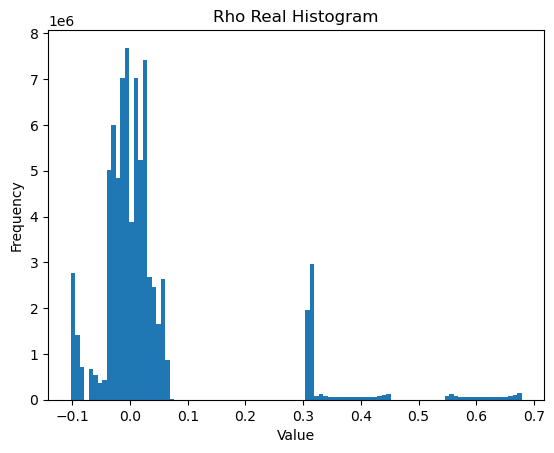

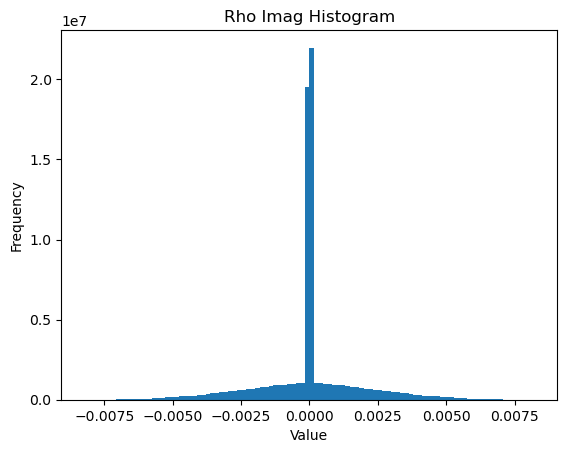

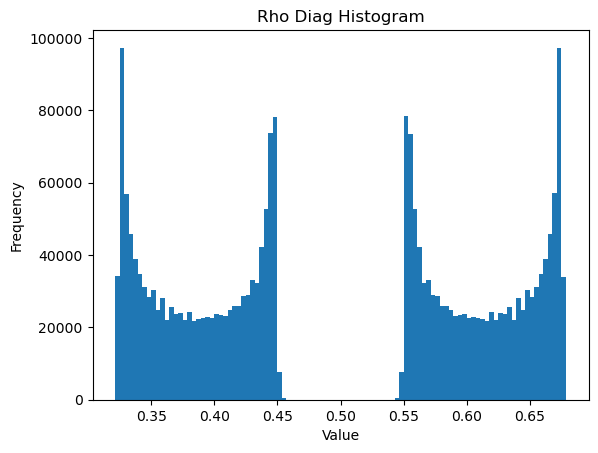

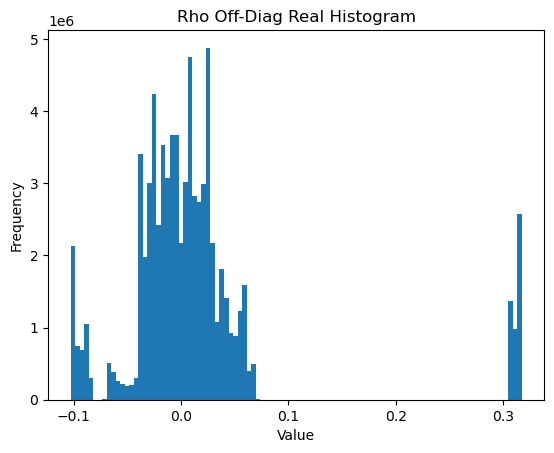

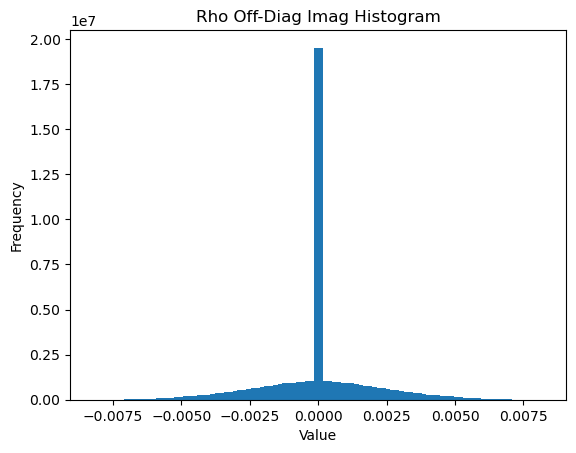

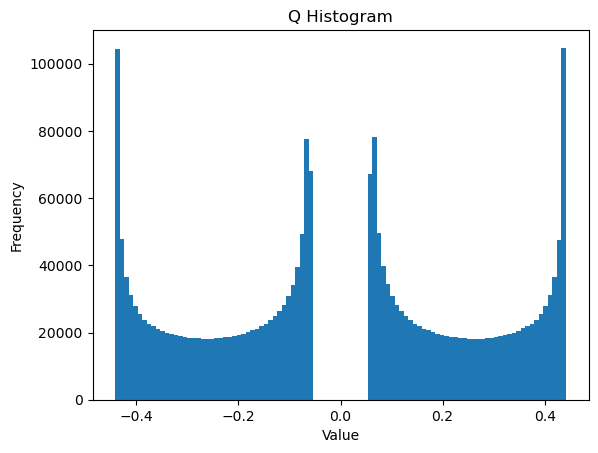

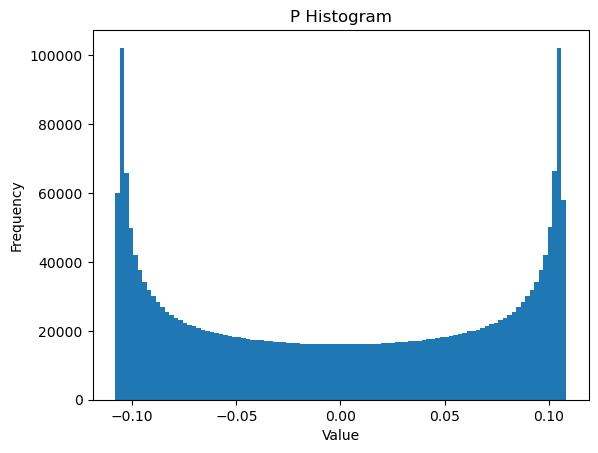

In [6]:
print_min_max(data)
plot_dist(data)

Min/Max and Histogram for Derivatives

Rho Real             Min:    -0.0236  Max:     0.0236  Mean:  -0.0000  Std:   0.0026
Rho Imag             Min:    -0.0115  Max:     0.0115  Mean:   0.0000  Std:   0.0021
Rho Diag             Min:    -0.0236  Max:     0.0236  Mean:  -0.0000  Std:   0.0083
Rho Off-Diag Real    Min:    -0.0149  Max:     0.0149  Mean:  -0.0000  Std:   0.0022
Rho Off-Diag Imag    Min:    -0.0115  Max:     0.0115  Mean:   0.0000  Std:   0.0021
Q                    Min:    -0.0325  Max:     0.0325  Mean:   0.0000  Std:   0.0225
P                    Min:    -0.0227  Max:     0.0227  Mean:  -0.0000  Std:   0.0126


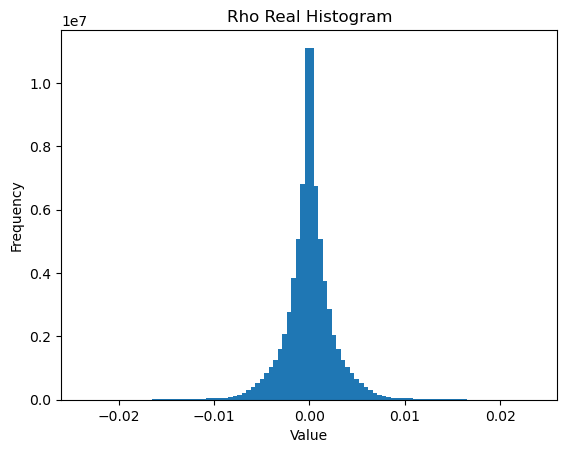

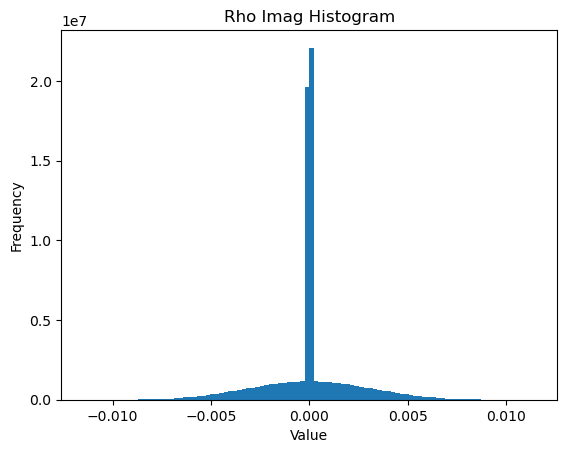

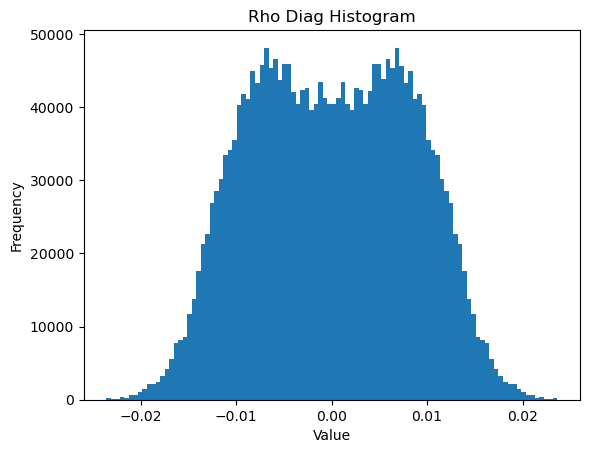

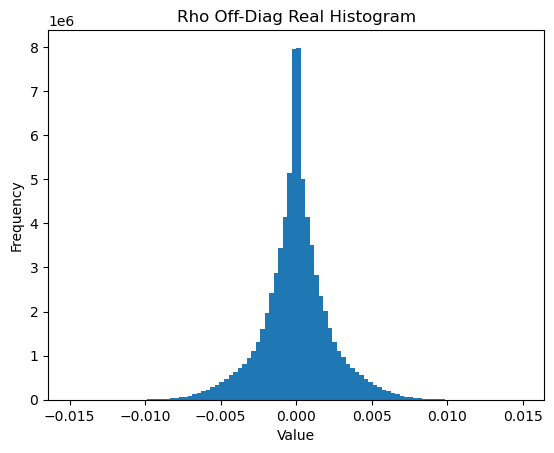

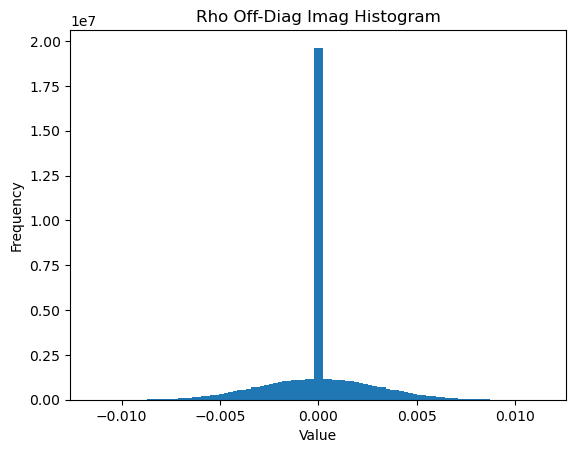

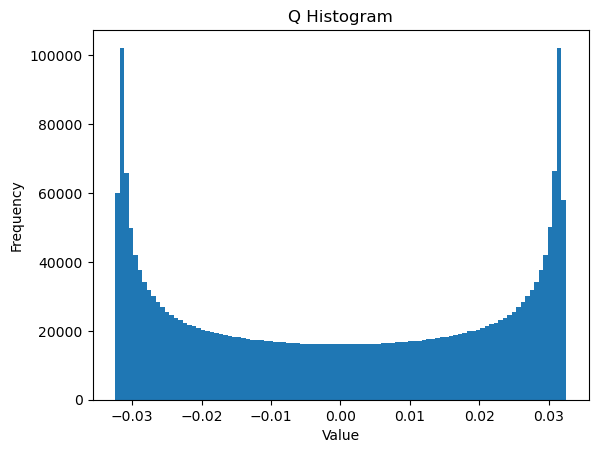

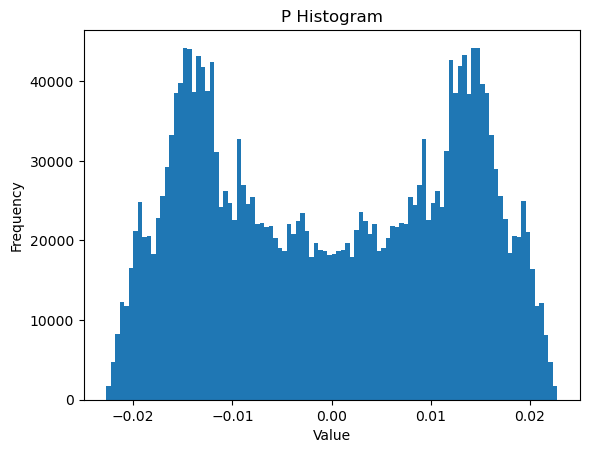

In [7]:
derivatives = torch_calc_derivatives_to_numpy(data, **physical_params)
print_min_max(derivatives)
plot_dist(derivatives)

Min/Max and Histogram for Deltas

Rho Real             Min:    -0.0139  Max:     0.0139  Mean:  -0.0000  Std:   0.0015
Rho Imag             Min:    -0.0057  Max:     0.0057  Mean:  -0.0000  Std:   0.0012
Rho Diag             Min:    -0.0139  Max:     0.0139  Mean:   0.0000  Std:   0.0051
Rho Off-Diag Real    Min:    -0.0085  Max:     0.0085  Mean:  -0.0000  Std:   0.0013
Rho Off-Diag Imag    Min:    -0.0057  Max:     0.0057  Mean:   0.0000  Std:   0.0012
Q                    Min:    -0.0208  Max:     0.0208  Mean:   0.0000  Std:   0.0144
P                    Min:    -0.0144  Max:     0.0144  Mean:  -0.0000  Std:   0.0081


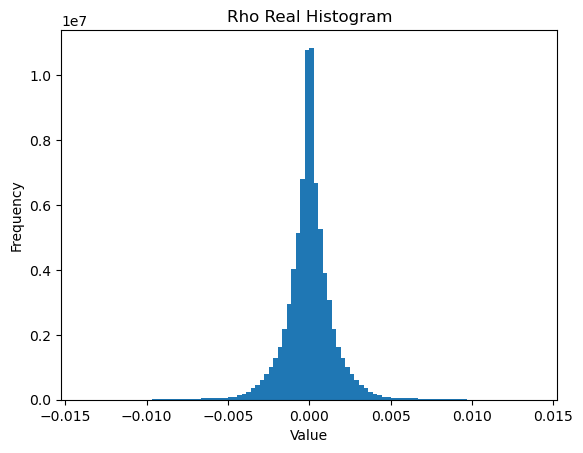

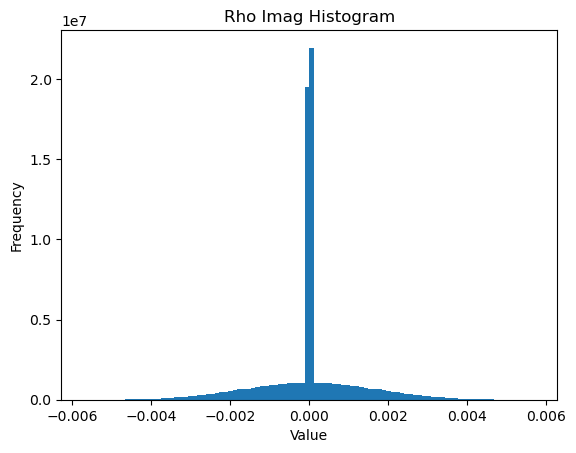

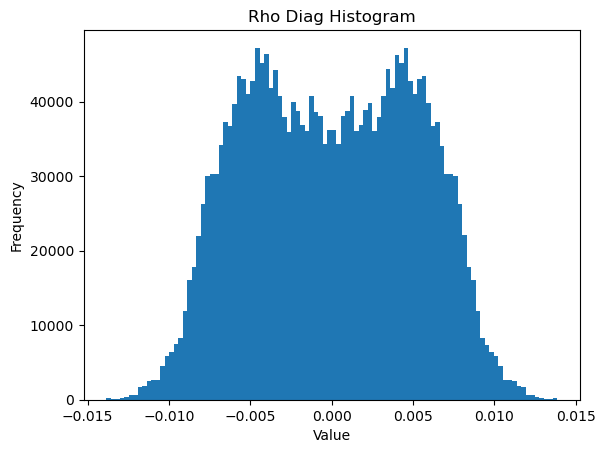

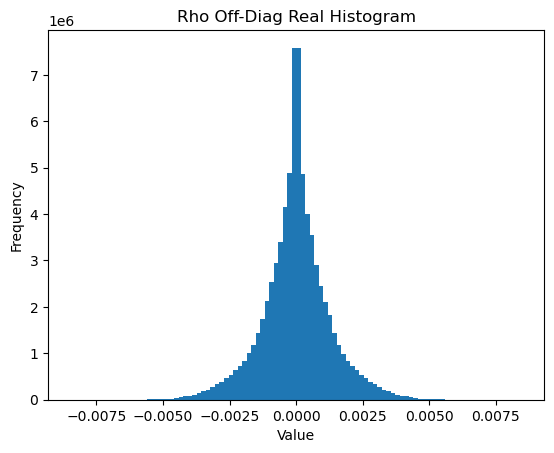

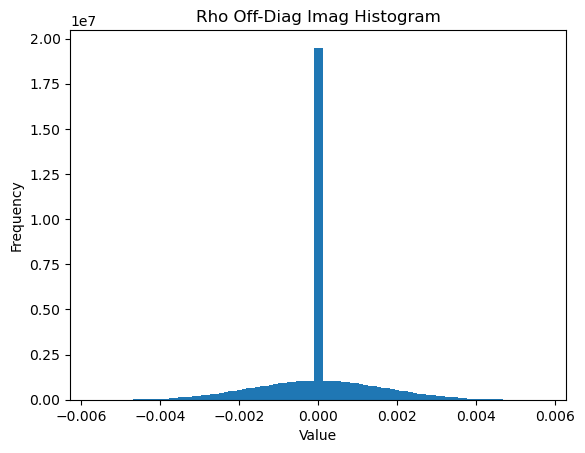

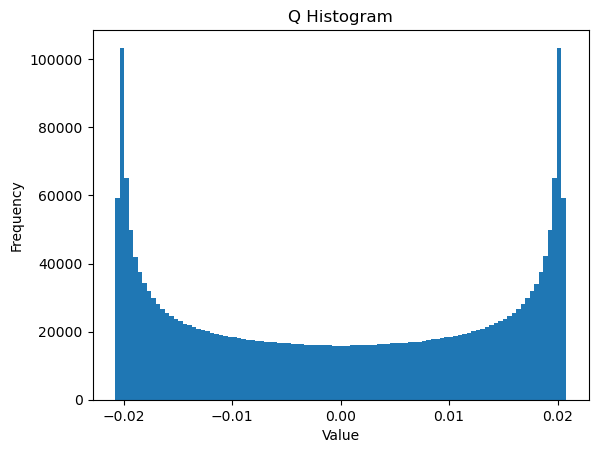

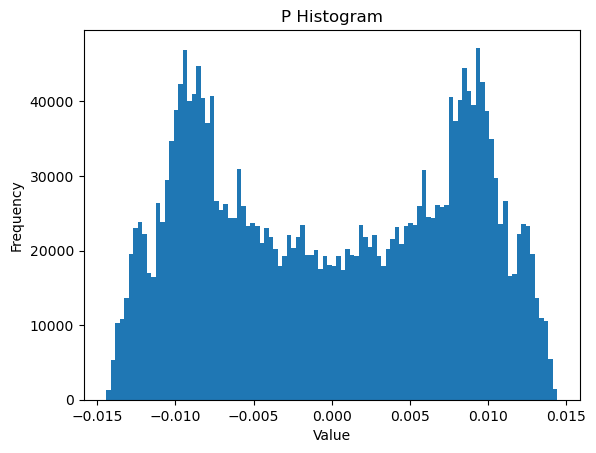

In [8]:
deltas = get_deltas(data)
print_min_max(deltas)
plot_dist(deltas)